In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import scienceplots

import time
import math
from bisect import bisect
import os
import sys
import random
from functools import partial
from decimal import Decimal
import numpy as np
import scipy.io as sio
import pysindy as ps
from tqdm import trange

sys.path.insert(0, '../')
from utils import *
from solvel0 import solvel0, MIOSR
from best_subset import backward_refinement, brute_force_all_subsets, brute_force, bnb
from UBIC import *
from bayesian_model_evidence import log_evidence

from skimage.restoration import estimate_sigma
import bm3d
from kneed import KneeLocator

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

from rdata import read_rds
from selective_inference import approximate_sigma, stepwise_regression, forward_stop_rule

from sklearn.preprocessing import StandardScaler
from sklearn import covariance
from sklearn.linear_model import (LinearRegression, Ridge, BayesianRidge, 
                                    Lasso, LassoCV, lars_path, ElasticNet, MultiTaskLasso, MultiTaskElasticNet, ARDRegression)
from abess import LinearRegression as AbessLinearRegression
from knockpy import KnockoffFilter, knockoff_stats, knockoffs
from knockpy.utilities import estimate_covariance
from scipy import stats
from statsmodels.stats.multitest import multipletests
from c2st.check import c2st # https://github.com/psteinb/c2st

from mbic import mbic, mbic2, ebic

from selective_inference import approximate_sigma, stepwise_regression, sfs_si, stepwise_selective_inference, subset_fdr
import fpsample
from dppy.finite_dpps import FiniteDPP

from si4pipeline import (
                        construct_pipelines, 
                        extract_features, 
                        initialize_dataset, 
                        intersection, 
                        lasso, 
                        marginal_screening, 
                        stepwise_feature_selection, 
                        union, 
                        PipelineManager
                        )

from pymcdm import weights as obj_w
from compromise_programming import optimal_decision, compromise_programming, mcdm
from pyRankMCDA.algorithm import rank_aggregation

import re

# Module-level constants: compiled once at import, reused on every call.
_FEATURE_PATTERN = re.compile(r'\^(\d+)|_([123]+)')
_SUBSCRIPT_TRANS = str.maketrans('123', 'xyz')

# Matches a letter, optionally followed by a power ^{...}, optionally followed by a derivative _{...}
# Group 1 captures the power digits. Group 2 captures the derivative letters.
_FACTOR_LATEX = re.compile(r'[a-zA-Z](?:\^\{(\d+)\})?(?:_\{([a-zA-Z]+)\})?')

def readable_feature_names(feature_names):
    """
    Transforms PySINDy feature names to a LaTeX-compatible format.
    Strips blank spaces from PySINDy's default polynomial library output.
    """
    def replacer(m):
        return f'^{{{m.group(1)}}}' if m.group(1) else f'_{{{m.group(2).translate(_SUBSCRIPT_TRANS)}}}'

    transformed = [
        _FEATURE_PATTERN.sub(replacer, f.replace('x0', 'u').replace('x1', 'v').replace(' ', ''))
        for f in feature_names
    ]
    return np.array(transformed, dtype=object)

def print_pde(est_coefficients, RHS, LHS='u_{t}', tol=1e-10):
    """
    Prints a given PDE, displaying only non-zero terms.
    Formats the output for copy-pasting into a LaTeX document using 4 decimal places.
    """
    terms = []
    is_first = True
    for c, feat in zip(est_coefficients, RHS):
        if abs(c) <= tol:
            continue

        # If the feature is the constant '1', don't print the '1'
        display_feat = "" if feat == '1' else feat

        # Purely real number
        if abs(c.imag) <= tol:
            val = abs(c.real)
            if c.real < 0:
                sign = "-" if is_first else " - "
            else:
                sign = "" if is_first else " + "
            terms.append(f"{sign}{val:.4f}{display_feat}")

        # Complex number
        else:
            sign = "" if is_first else " + "
            terms.append(f"{sign}({c.real:.4f} {c.imag:+.4f}i){display_feat}")

        is_first = False

    rhs_str = "".join(terms) if terms else "0"
    print(f"{LHS} = {rhs_str}")

In [2]:
target_name = 'u'
X_pre = np.load("../Cache/X_pre_GS_2025.npy")
uv_pre = np.load("../Cache/y_pre_GS_2025.npy")

### Ground truth ###
ground_indices_u = [0, 1, 8, 12, 18, 26]
ground_coeff_u = np.array([0.014, -0.014, -1.000, 0.020, 0.020, 0.020])
ground_indices_v = [2, 8, 13, 19, 27]
ground_coeff_v = np.array([-0.067, 1.0, 0.01, 0.01, 0.01])
feature_names = np.load("../Cache/feature_names_GS_2025.npy", allow_pickle=True)
feature_names = readable_feature_names(feature_names)

u_est_coefficients = np.linalg.lstsq(X_pre[:, ground_indices_u], uv_pre[:, 0], rcond=None)[0]
v_est_coefficients = np.linalg.lstsq(X_pre[:, ground_indices_v], uv_pre[:, 1], rcond=None)[0]
u_coefficient_error = 100 * abs(u_est_coefficients - ground_coeff_u) / abs(ground_coeff_u)
v_coefficient_error = 100 * abs(v_est_coefficients - ground_coeff_v) / abs(ground_coeff_v)

print_pde(u_est_coefficients, feature_names[ground_indices_u], LHS='u_{t}')
print_pde(v_est_coefficients, feature_names[ground_indices_v], LHS='v_{t}')
print(u_coefficient_error.mean(), u_coefficient_error.std())
print(v_coefficient_error.mean(), v_coefficient_error.std())

u_{t} = 0.0140 - 0.0140u - 0.9999uv^{2} + 0.0200u_{zz} + 0.0200u_{yy} + 0.0200u_{xx}
v_{t} = -0.0670v + 1.0000uv^{2} + 0.0100v_{zz} + 0.0100v_{yy} + 0.0100v_{xx}
0.028098924724832053 0.04436672692874955
0.006167686444490715 0.00416077732184237


In [3]:
def term_complexity(term, plus_one=True):
    """
    Calculates the complexity of a term formatted in LaTeX.
    Complexity = degree (sum of powers) + differentiation order (sum of spatial derivatives).
    """
    deg = diff = 0
    for m in _FACTOR_LATEX.finditer(term):
        # m.group(1) is the power (e.g., '2' from u^{2}). If none, the power is implicitly 1.
        deg += int(m.group(1)) if m.group(1) else 1

        # m.group(2) is the derivative string (e.g., 'xx' from u_{xx}). Its length is the diff order.
        diff += len(m.group(2)) if m.group(2) else 0

    return deg + diff + (1 if plus_one else 0)

def measure_fdr_power(rejections, nonnulls, p):
    def fdp_power(selected, ground_truth):
        selected_binary = selected != 0
        ground_truth_binary = ground_truth != 0
    
        true_positive = np.sum(selected_binary & ground_truth_binary)
        false_positive = np.sum(selected_binary & ~ground_truth_binary)
    
        fdp = false_positive / max(1, np.sum(selected_binary))
        power = true_positive / max(1, np.sum(ground_truth_binary))

        return fdp, power
    
    selected  = np.zeros(p, dtype=bool)
    selected[rejections] = True
    
    ground_truth = np.zeros(p)
    ground_truth[nonnulls] = True

    return fdp_power(selected, ground_truth)

def multitask_joint_pvalues(X, Y, fit_intercept=False):
    """
    Compute one joint p-value per feature for multitask linear regression
    using a Wald chi-square test.

    H0: feature j has no effect on any task
    H1: feature j affects at least one task

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Design matrix.
    Y : ndarray of shape (n_samples, n_tasks)
        Multi-output target.
    fit_intercept : bool, default=True
        Whether to include an intercept in the regression.

    Returns
    -------
    p_values : ndarray of shape (n_features,)
        One p-value per feature (excluding intercept).
    """
    n, p = X.shape
    k = Y.shape[1]

    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(X, Y)
    B = model.coef_.T  # (p, k)

    # Residuals
    E = Y - model.predict(X)
    # Residual covariance across tasks
    Sigma = np.cov(E, rowvar=False, bias=False)
    # Inverse of X'X
    Xc = X - X.mean(axis=0) if fit_intercept else X
    XtX_inv = np.linalg.inv(Xc.T @ Xc)

    # Wald test (vectorized over features)
    Sigma_inv = np.linalg.inv(Sigma)
    quad_forms = np.einsum(
        "ij,jk,ik->i",
        B,
        Sigma_inv,
        B
    )

    W = quad_forms / np.diag(XtX_inv)
    p_values = 1 - stats.chi2.cdf(W, df=k)

    return p_values

pv_preprocessing = None # None, 'nonrobust', 'parametric' or 'over_conditioning' (forward_regression, omp, lar, lasso), 'si_R' (forward_regression)
if pv_preprocessing is not None:
    X_test = StandardScaler(with_std=True).fit_transform(X_pre)
    uv_test = StandardScaler(with_std=False).fit_transform(uv_pre)
    if pv_preprocessing in {'parametric', 'over_conditioning'}:
        p_sel = []
        for i in range(2):
            y_test = uv_test[:, i]
            coeff_path = stepwise_regression(X_test, y_test.ravel(), method='linear', kwargs={'alpha': 1e-5, 'ic_type': 'ebic', 'cv': 3, 'mio': True, 'X_norm': None})
            print(coeff_path)
            sigma = approximate_sigma(X_test[:, coeff_path], y_test)
            manager = stepwise_selective_inference(support_size=len(coeff_path))
            _, p_values = manager.inference(X_test[:, coeff_path], y_test, sigma, inference_mode=pv_preprocessing)
            alpha = 0.1
            for _ in range(100):
                stop_at = forward_stop_rule(p_values, alpha=alpha)[0]
                p_sel = np.union1d(p_sel, coeff_path[:stop_at + 1])
                if len(p_sel) > 1:
                    break
                alpha += 0.01
            del y_test
    elif pv_preprocessing == 'si_R':
        p_sel = np.union1d((read_rds("../R/R_data/fsInf_screening_GS_u_sample10000_alpha10.rds")['vars'] - 1).astype(int), 
                           (read_rds("../R/R_data/fsInf_screening_GS_v_sample10000_alpha10.rds")['vars'] - 1).astype(int))
    elif pv_preprocessing == 'mtl':
        p_values = multitask_joint_pvalues(X_pre, uv_test)
        p_sel = np.where(multipletests(p_values, alpha=alpha, method='fdr_bh')[0])[0]
    else:
        for i in range(2):
            p_values = sm.OLS(uv_test[:, i], X_pre).fit(cov_type=pv_preprocessing).pvalues
            p_sel = np.union1d(p_sel, np.where(multipletests(p_values, alpha=alpha, method='fdr_bh')[0])[0])
            
    p_sel = np.sort(p_sel).astype(int)
    assert set(ground_indices_u).issubset(p_sel) and set(ground_indices_v).issubset(p_sel)
    ground_indices_u = np.where(np.isin(p_sel, ground_indices_u))[0]
    ground_indices_v = np.where(np.isin(p_sel, ground_indices_v))[0]
    print(p_sel, feature_names[p_sel])
    X_pre = X_pre[:, p_sel]
    feature_names = feature_names[p_sel]

X_pre_top = StandardScaler(with_std=True).fit_transform(X_pre)
uv_pre = StandardScaler(with_std=False).fit_transform(uv_pre)
true_coefficients = np.zeros(len(feature_names))
if target_name == 'u':
    y_pre = uv_pre[:, 0:1]
    true_coefficients[ground_indices_u] = ground_coeff_u
elif target_name == 'v':
    y_pre = uv_pre[:, 1:2]
    true_coefficients[ground_indices_v] = ground_coeff_v
bias_term = X_pre_top[:, 0:1]
nonnulls = np.nonzero(true_coefficients)[0]

fsInf_active_u = read_rds("../R/R_data/fsInf_active_GS_u_sample10000_alpha10.rds")
fsInf_active_u = (fsInf_active_u.get('vars') - 1).astype(int)[:int(fsInf_active_u.get('khat')[0])]
fsInf_active_v = read_rds("../R/R_data/fsInf_active_GS_v_sample10000_alpha10.rds")
fsInf_active_v = (fsInf_active_v.get('vars') - 1).astype(int)[:int(fsInf_active_v.get('khat')[0])]
print("fsInf_active_u:", len(fsInf_active_u), fsInf_active_u, measure_fdr_power(fsInf_active_u, ground_indices_u, p=X_pre.shape[1]))
print("fsInf_active_v:", len(fsInf_active_v), fsInf_active_v, measure_fdr_power(fsInf_active_v, ground_indices_v, p=X_pre.shape[1]))
fsInf_bic_u = read_rds("../R/R_data/fsInf_screening_GS_u_sample10000_alpha10.rds")
fsInf_bic_u = (fsInf_bic_u.get('vars') - 1).astype(int)[:int(fsInf_bic_u.get('khat')[0])]
fsInf_bic_v = read_rds("../R/R_data/fsInf_screening_GS_v_sample10000_alpha10.rds")
fsInf_bic_v = (fsInf_bic_v.get('vars') - 1).astype(int)[:int(fsInf_bic_v.get('khat')[0])]
print("fsInf_bic_u:", len(fsInf_bic_u), fsInf_bic_u, measure_fdr_power(fsInf_bic_u, ground_indices_v, p=X_pre.shape[1]))
print("fsInf_bic_v:", len(fsInf_bic_v), fsInf_bic_v, measure_fdr_power(fsInf_bic_v, ground_indices_v, p=X_pre.shape[1]))

fsInf_active_u: 9 [ 1 26 18  8 12  0 25  7  3] (0.3333333333333333, 1.0)
fsInf_active_v: 6 [ 2 27  8 19 13  5] (0.16666666666666666, 1.0)
fsInf_bic_u: 7 [ 1 26 18  8 12  0 25] (0.8571428571428571, 0.2)
fsInf_bic_v: 5 [ 2 27  8 19 13] (0.0, 1.0)


### s_max

In [4]:
from skglm import MCPRegression, Lasso
from skglm.experimental import SqrtLasso
from scipy.stats import norm
# statsmodels
from scipy.special import comb
from sklearn.base import clone
from sklearn.model_selection import KFold, cross_val_score

def lambda_max(X, y):
    """
    Compute lambda_max for MCP (same as Lasso): max abs correlation / n.
    Assumes X standardized, y centered.
    """
    n, p = X.shape
    return np.max(np.abs(X.T @ y)) / n

# c > 0
def plugin_lasso_lambda(X, y, c=0.25, t=np.finfo(np.float32).tiny, homoskedastic=True):
    n, p = X.shape
    assert n == len(y)

    lambda_value = 4*np.sqrt((t**2 + 2 * np.log(p)) / n)

    if homoskedastic:
        ols_result = sm.OLS(y, X).fit()
        # var = y.T.dot(y) / n
        var = np.sum(ols_result.resid**2) / ols_result.df_resid
        sigma = np.sqrt(var)
        lambda_value = sigma * lambda_value

    return float(c*lambda_value)

def rebic(y_true, y_pred, n_params, n_features, gamma=1, robust=False, exact=True, sic=False):
    if y_true.shape != y_pred.shape:
        y_true = y_true.reshape(y_pred.shape)
    n_samples = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    bic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples)
    if sic:
        return bic    
    rss0 = (np.linalg.norm(y_true, ord=2)**2)/n_samples
    if exact:
        ebic = bic + 2*gamma*np.log(comb(n_features, n_params))
        rebic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples/(2*np.pi)) + (n_params+2)*np.log(rss0/rss) + 2*gamma*np.log(comb(n_features, n_params))
    else:
        ebic = bic + 2*n_params*gamma*np.log(n_features)
        rebic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples/(2*np.pi)) + (n_params+2)*np.log(rss0/rss) + 2*n_params*gamma*np.log(n_features)
    if not robust:
        return ebic
    return rebic

def rebic_scorer(est, X, y, gamma=1, robust=False, exact=True, sic=False):
    pred = est.predict(X)
    assert pred.shape == y.shape
    n_samples, n_tasks = pred.shape
    n_params = np.count_nonzero(est.coef_) // n_tasks
    n_features = np.prod(est.coef_.shape) // n_tasks
    return np.mean([rebic(y[:, i], pred[:, i], n_params, n_features, 
                          gamma=gamma, robust=robust, exact=exact, sic=sic) for i in range(n_tasks)])

def penalized_mse_scorer(est, X, y, l0_penalty=None):
    pred = est.predict(X)
    if y.shape != pred.shape:
        y = y.reshape(pred.shape)
    rss = np.linalg.norm(y - est.predict(X), 2)
    n_params = np.count_nonzero(est.coef_) + (1 if est.fit_intercept else 0)
    if l0_penalty is None:
        l0_penalty = 1e-3 * np.linalg.cond(X)
    return rss + l0_penalty * n_params

cv = 3
l1_mse = 1; l1_ic = 1
mse_min = np.inf; ic_min = np.inf
# penalized_mse_scorer = partial(penalized_mse_scorer, l0_penalty=None)
penalized_mse_scorer = partial(penalized_mse_scorer, l0_penalty=10**sci_format(min(np.linalg.lstsq(X_pre_top, uv_pre, rcond=None)[1]))[1])
rebic_scorer = partial(rebic_scorer, gamma=1, robust=False, sic=False)

for c in (0.5, 0.75, 1):
    est_lambda = min(plugin_lasso_lambda(X_pre_top, uv_pre[:, 0], c=c, t=1e-6, homoskedastic=True),
                     plugin_lasso_lambda(X_pre_top, uv_pre[:, 1], c=c, t=1e-6, homoskedastic=True))
    multitask_lasso = MultiTaskElasticNet(alpha=est_lambda, fit_intercept=False, max_iter=2000)
    avg_mse_score = cross_val_score(clone(multitask_lasso), X_pre_top, uv_pre, cv=cv, scoring=penalized_mse_scorer).mean()
    avg_ic_score = rebic_scorer(multitask_lasso.fit(X_pre_top, uv_pre), X_pre_top, uv_pre)
    if avg_mse_score < mse_min:
        mse_min = avg_mse_score
        l1_mse = c
    if avg_ic_score < ic_min:
        ic_min = avg_ic_score
        l1_ic = c
    print(c, avg_mse_score, avg_ic_score)

l1_c = max(l1_mse, l1_ic)
est_lambda = min(plugin_lasso_lambda(X_pre_top, uv_pre[:, 0], c=l1_c, t=1e-6, homoskedastic=True), 
                 plugin_lasso_lambda(X_pre_top, uv_pre[:, 1], c=l1_c, t=1e-6, homoskedastic=True))
multitask_lasso = MultiTaskElasticNet(alpha=est_lambda, fit_intercept=False, max_iter=2000).fit(X_pre_top, uv_pre)
s_max = np.count_nonzero(multitask_lasso.coef_)//2
l1_c, s_max

0.5 2.158108394902432e-06 -348357.6624284485
0.75 2.158652694930494e-06 -348334.46387987636
1 2.1599699741379234e-06 -348321.5776250268


(0.5, 18)

In [5]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

def rebic_scorer(est, X, y, gamma=1, robust=False, exact=True, sic=False):
    n_samples = len(y)
    pred = est.predict(X)
    assert y.shape == pred.shape
    rss = np.sum((y - est.predict(X)) ** 2)
    n_params = np.count_nonzero(est.coef_)
    n_features = np.prod(est.coef_.shape)
    if getattr(est, 'fit_intercept', None) or getattr(est, 'intercept_', None):
        n_params += 1
        n_features += 1
    bic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples)
    if sic:
        return bic
    ebic = bic + 2*gamma*np.log(comb(n_features, n_params, exact=exact)) # requires from scipy.special import comb
    if not robust:
        return ebic
    rss0 = (np.linalg.norm(y, ord=2)**2)/n_samples
    if exact:
        rebic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples/(2*np.pi)) + (n_params+2)*np.log(rss0/rss) + 2*gamma*np.log(comb(n_features, n_params))
    else:
        rebic = n_samples*np.log(rss/n_samples) + n_params*np.log(n_samples/(2*np.pi)) + (n_params+2)*np.log(rss0/rss) + 2*n_params*gamma*np.log(n_features)
    return rebic

class SRSelector(BaseEstimator, RegressorMixin):
    def __init__(self, s_max=10, alpha=0.05, criteria='coefficient_value', normalize_columns=True, kappa_min_exp=-9, kappa_max_exp=0, method_name='ssr'):
        self.s_max = s_max
        self.alpha = alpha
        self.criteria = criteria # "coefficient_value" or "model_residual".
        self.normalize_columns = normalize_columns
        self.kappa_min_exp = kappa_min_exp
        self.kappa_max_exp = kappa_max_exp
        self.method_name = method_name
        self.fit_intercept = False # needed for compatibility
        self.intercept_ = 0 # needed for compatibility
        
    def fit(self, X, y):
        X, y = check_X_y(X, y)
        
        self.selected_features_ = None
        if self.method_name == 'frols':
            model = ps.FROLS(kappa=None, max_iter=s_max, alpha=self.alpha, normalize_columns=self.normalize_columns, unbias=True)
        elif self.method_name == 'mcp':
            model = MCPRegression(alpha=0, fit_intercept=False, max_iter=100)
        else:
            model = ps.SSR(kappa=0, alpha=self.alpha, criteria=self.criteria, normalize_columns=self.normalize_columns, max_iter=10000, unbias=True)
        model.fit(X, y)
        nonzero = np.nonzero(model.coef_.ravel())[0]
        
        if len(nonzero) <= self.s_max:
            self.model_ = model
            self.selected_features_ = nonzero
        else:
            for kappa_exp in range(self.kappa_min_exp, self.kappa_max_exp + 1):
                if self.method_name == 'frols':
                    model = ps.FROLS(kappa=10**kappa_exp, max_iter=s_max, alpha=self.alpha, normalize_columns=self.normalize_columns, unbias=True)
                elif self.method_name == 'mcp':
                    model = MCPRegression(alpha=10**kappa_exp, fit_intercept=False, max_iter=100)                    
                else:
                    model = ps.SSR(kappa=10**kappa_exp, alpha=self.alpha, criteria=self.criteria, normalize_columns=self.normalize_columns, max_iter=10000, unbias=True)
                model.fit(X, y)
                nonzero = np.nonzero(model.coef_.ravel())[0]
                
                if len(nonzero) <= self.s_max:
                    self.model_ = model
                    self.selected_features_ = nonzero
                    break

        if self.selected_features_ is None:
            # fallback to last model
            self.model_ = model
            self.selected_features_ = nonzero
        
        self.coef_ = self.model_.coef_
        return self

    def predict(self, X):
        check_is_fitted(self)
        return self.model_.predict(check_array(X)).ravel()

# testing
# lr = SRSelector(s_max, ssr_config[0], ssr_config[1], normalize_columns=True, method_name='ssr')
ssr_config = None
min_ssr_ic = 1e6
for criteria in ["model_residual", "coefficient_value"]:
    for alpha in sorted([10 ** _ for _ in range(-2, 2)] + [5 * 10 ** _ for _ in range(-2, 2)])[:-1]:
        ssr_selector = SRSelector(s_max=18, alpha=alpha, criteria=criteria, normalize_columns=True, method_name='mcp')
        # ssr_ic = sm.OLS(y_pre.ravel(), X_pre_top[:, ssr_selector.fit(X_pre_top, y_pre.ravel()).selected_features_]).fit().bic
        ssr_ic = np.mean(cross_val_score(ssr_selector, X_pre_top, y_pre.ravel(), 
                                         cv=KFold(n_splits=3, shuffle=True, random_state=0), 
                                         scoring=rebic_scorer))

        # print(alpha, criteria, ssr_ic)
        if ssr_ic < min_ssr_ic:
            min_ssr_ic = ssr_ic
            ssr_config = alpha, criteria
            
ssr_config, min_ssr_ic

((0.01, 'model_residual'), -72464.95892567073)

### Knockoffs

In [6]:
## from abess import LinearRegression as AbessLinearRegression
from sklearn.covariance import LedoitWolf, OAS, GraphicalLasso, GraphicalLassoCV, MinCovDet, EllipticEnvelope
from sklearn.utils import resample
from pyriemann.estimation import Covariances
from hidimstat import ModelXKnockoff
from hidimstat.samplers import GaussianKnockoffs
from hidimstat.knockoffs_sampler import GaussianSampler
from hidimstat.knockoffs_utilities import estimate_covariance, CovEstimator
from hidimstat.statistical_tools.multiple_testing import fdp_power
# from knockpy import KnockoffFilter, knockoff_stats, knockoffs
from scipy import stats
from statsmodels.stats.multitest import multipletests
from c2st.check import c2st # https://github.com/psteinb/c2st
from deep_knockoffs import DeepKnockoffGenerator
from deep_knockoffs.diagnostics import compare_covariance_estimators

# Can be merged with CovEstimator in hidimstat.knockoffs_utilities
class CovarianceEstimator:
    def __init__(self, estimator="lwf", kwargs=None):
        kwargs = {} if kwargs is None else dict(kwargs)
        self.estimator = Covariances(estimator=estimator, **kwargs)
        self.covariance_ = None
    def fit(self, X, y=None):
        self.covariance_ = self.estimator.fit_transform(np.expand_dims(X.T, 0))[0]
        return self
        
n_repeats = 100
importance_type = "shap_difference_native"
generator_method = None # equicorrelated, sdp, mvr, maxent, and ci.
fdr_control = "ebh"
centered = True
use_kopi = False
gamma = 0.5
offset = 1
s_min = 2
random_state = 1; np.random.seed(random_state)
shrinkage_tol = 1e-2
ridge_alpha = 1e-5
# lr = LassoCV(cv=3, fit_intercept=False, max_iter=10000)
# lr = AbessLinearRegression(path_type='seq', support_size=s_max, fit_intercept=False, alpha=ridge_alpha, cv=cv, screening_size=0, important_search=0)
lr = AbessLinearRegression(path_type='gs', s_min=0, s_max=s_max, fit_intercept=False, alpha=ridge_alpha, cv=cv, screening_size=0, important_search=0)
# lr = SRSelector(s_max, ssr_config[0], ssr_config[1], normalize_columns=True, method_name='ssr')
if not hasattr(lr, 's_max'):
    s_max = None
else:
    print("s_max:", s_max)
# cov_estimator = CovarianceEstimator("mcd") # "mcd", "sch"
# cov_estimator = MinCovDet(assume_centered=True) # EllipticEnvelope(assume_centered=True)
glasso = GraphicalLassoCV(alphas=np.logspace(-1, 0, 50), cv=cv, assume_centered=True, max_iter=1000) # GraphicalLassoCV(cv=cv, assume_centered=True)
if centered: glasso.fit(StandardScaler().fit_transform(X_pre_top))
else: glasso.fit(X_pre_top)
glasso = CovEstimator(shrinkage="graphicallasso", shrinkage_tol=shrinkage_tol, kwargs={"alpha": glasso.alpha_, "assume_centered": True, "max_iter": 1000})
ledoitwolf = CovEstimator(shrinkage="ledoitwolf", shrinkage_tol=shrinkage_tol, kwargs={"assume_centered": True, "store_precision": True})

best_cov_name = None # None or 'deep_knockoffs'
best_cov_estimator = None
deep_knockoffs = False
if best_cov_name == 'deep_knockoffs':
    deep_knockoffs = True
    best_cov_name, best_cov_estimator, _, _ = compare_covariance_estimators(X_pre_top, 
                                                                            methods=("empirical", "ledoit_wolf", "oas", "graphical_lasso", "min_cov_det"))
    print(best_cov_name)
    cov_estimators = (best_cov_estimator,)
else:
    cov_estimators = (glasso, ledoitwolf)

# Fit importances ONCE per (cov_estimator, uv_target) pair
fitted_models = {}
for cov_estimator in cov_estimators:
    for uv_idx in range(2):
        ko_generator = GaussianKnockoffs(cov_estimator=cov_estimator, tol=1e-16, generator_method=generator_method)
        model_x_knockoff = ModelXKnockoff(estimator=clone(lr), ko_generator=ko_generator,
                                          importance_type=importance_type, n_repeats=n_repeats,
                                          centered=centered, n_jobs=4, random_state=random_state)
        model_x_knockoff.fit_importance(X_pre_top, uv_pre[:, uv_idx])
        fitted_models[(id(cov_estimator), uv_idx)] = model_x_knockoff

s_max: 18


In [7]:
# Sweep FDR levels
fdr = 1/2
ebh_fdr = 1/2
fdr_max = fdr / (1 - fdr)
ko_scorer = rebic_scorer
fdrs = np.array([fdr for _ in range(len(cov_estimators))])
rejections = np.array([], dtype=int)
done = [False] * len(cov_estimators)
best_cov_estimator = None
best_mx_knockoff = None
min_ko_score = 1e6

while not (all(done) or deep_knockoffs):
    for i, cov_estimator in enumerate(cov_estimators):
        if done[i]:
            continue
        print(fdrs[i], cov_estimator.shrinkage)
        eval_selection_uv = []
        for uv_idx in range(2):
            model_x_knockoff = fitted_models[(id(cov_estimator), uv_idx)]
            eval_aggregation = model_x_knockoff.fdr_selection(
                fdr=fdrs[i], ebh_fdr=ebh_fdr, fdr_control=fdr_control, evalues=True, s_max=s_max,
                use_kopi=use_kopi, gamma=gamma, offset=offset,
            )
            eval_selection = np.where(eval_aggregation > 0)[0]
            eval_selection_uv = np.union1d(eval_selection_uv, eval_selection.astype(int))

        eval_selection_uv = eval_selection_uv.astype(int)
        if len(eval_selection_uv) < s_min:
            fdrs[i] += 0.01
            if fdrs[i] > fdr_max:
                done[i] = True
        else:
            done[i] = True
            if hasattr(lr, 's_max') and len(eval_selection_uv) > s_max:
                print(eval_selection_uv)
                eval_selection_uv = eval_selection_uv[np.nonzero(
                    ps.MIOSR(target_sparsity=s_max, alpha=ridge_alpha,
                             unbias=True, normalize_columns=False
                    ).fit(X_pre_top[:, eval_selection_uv], y_pre).coef_[0]
                )[0]]
            ko_score = cross_val_score(
                LinearRegression(fit_intercept=False),
                X_pre_top[:, eval_selection_uv], y_pre,
                cv=cv, scoring=ko_scorer,
            ).mean()
            print(eval_selection_uv, ko_score)

            if ko_score < min_ko_score:
                fdr = fdrs[i]
                best_cov_estimator = cov_estimator
                best_mx_knockoff = model_x_knockoff
                min_ko_score = ko_score
                rejections = eval_selection_uv

if deep_knockoffs:
    eval_selection_uv = []
    for uv_idx in range(2):
        dkg = DeepKnockoffGenerator(epochs=100, epoch_length=5, knockoff_type='sdp', cov_estimator=best_cov_name)
        best_mx_knockoff = ModelXKnockoff(estimator=clone(lr), ko_generator=dkg,
                                          importance_type=importance_type, n_repeats=n_repeats,
                                          centered=centered, n_jobs=4, random_state=random_state)
        best_mx_knockoff.fit_importance(X_pre_top, uv_pre[:, uv_idx])
        eval_aggregation = best_mx_knockoff.fdr_selection(fdr=fdrs[i], fdr_control=fdr_control, evalues=True, s_max=s_max,
                                                          use_kopi=use_kopi, gamma=gamma, offset=offset)
        eval_selection = np.where(eval_aggregation > 0)[0]
        eval_selection_uv = np.union1d(eval_selection_uv, eval_selection.astype(int))

    eval_selection_uv = eval_selection_uv.astype(int)
    rejections = eval_selection_uv

assert best_mx_knockoff is not None and len(rejections) >= s_min
if target_name == 'u':
    assert set(ground_indices_u).issubset(set(rejections))
    print("OK!")
elif target_name == 'v':
    assert set(ground_indices_v).issubset(set(rejections))
    print("OK!")
else:
    assert False

rej = np.zeros(len(feature_names), dtype=np.int8); rej[rejections] = 1
# print(fdr, len(rejections), rejections, feature_names[rejections])
# print(fdp_power(rej, true_coefficients != 0))
len(rejections), rejections, fdp_power(rej, true_coefficients != 0)

0.5 graphicallasso
[ 0  1  2  7  8  9 12 13 18 19 25 26] -113934.8428704692
0.5 ledoitwolf
[ 0  1  2  4  5  6  7  8  9 11 12 13 14 15 16 18 19 24 25 26 27]
Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-30
[ 0  1  8 12 18 26] -113990.3249427929
OK!


(6, array([ 0,  1,  8, 12, 18, 26]), (0.0, 1.0))

In [8]:
from adages_v1 import agg_adages, agg_adages_mod
from adages_v2 import agg_ADAGES, agg_ADAGES_mod

# Aggregate knockoffs using other procedures
mx_knockoff_rejections = best_mx_knockoff.aggregate_ko(best_mx_knockoff.ko_fdr_selection(fdr), ako=False)
print("mx knockoff rejections:", mx_knockoff_rejections, end='\n\n')
if len(mx_knockoff_rejections) == 1 and len(mx_knockoff_rejections[0]) > 0:
    mx_knockoff_rejections = np.array(mx_knockoff_rejections[0], dtype=int)
    rejections = mx_knockoff_rejections
ako_rejections = best_mx_knockoff.aggregate_ko(best_mx_knockoff.ko_fdr_selection(fdr, ako_nums=5), ako=True)
ako_rejections = np.array(ako_rejections[0], dtype=int)
print("ako rejections:", ako_rejections, measure_fdr_power(ako_rejections, nonnulls, X_pre_top.shape[1]), end='\n\n')
print("adages:", agg_adages([np.nonzero(_)[0].tolist() for _ in best_mx_knockoff.ko_fdr_selection(fdr)], X_pre_top.shape[1])['selected'], 
agg_ADAGES([np.nonzero(_)[0].tolist() for _ in best_mx_knockoff.ko_fdr_selection(fdr)], X_pre_top.shape[1])['Shat'])
print(measure_fdr_power(agg_adages([np.nonzero(_)[0].tolist() for _ in best_mx_knockoff.ko_fdr_selection(fdr)], X_pre_top.shape[1])['selected'], nonnulls, X_pre_top.shape[1]), end='\n\n')
print("modified adages:", agg_adages_mod([np.nonzero(_)[0].tolist() for _ in best_mx_knockoff.ko_fdr_selection(fdr)], X_pre_top.shape[1])['selected'], 
agg_ADAGES_mod([np.nonzero(_)[0].tolist() for _ in best_mx_knockoff.ko_fdr_selection(fdr)], X_pre_top.shape[1])['Shat'])

# Check power
print("rejections:", rejections, feature_names[rejections], measure_fdr_power(rejections, nonnulls, p=X_pre_top.shape[1]))
rej = np.zeros(len(feature_names), dtype=np.int8); rej[rejections] = 1
fdp_power(rej, true_coefficients != 0)

# Check intercept
ols_without_bias = sm.OLS(y_pre.ravel(), X_pre_top[:, rejections]).fit()
ols_with_bias = sm.OLS(y_pre.ravel(), np.hstack((bias_term, X_pre_top[:, rejections]))).fit()
if ols_with_bias.pvalues[0] < 0.1 and  ols_without_bias.bic - ols_with_bias.bic > 2: # weak evidence
    assert True
    if '1' in feature_names:
        print("bias (already in feature_names) should be in included in rejections.")
        rejections = np.sort(list(set(rejections).union({0})))
    else:
        print("bias (missing from feature_names) should be in included in rejections.")
        X_pre_top = np.hstack((bias_term, X_pre_top))
        feature_names = np.insert(feature_names, 0, '1')
        rejections = np.insert(rejections + 1, 0, 0)
        # needs verification
        true_coefficients = np.insert(true_coefficients, 0, 0)
        nonnulls = np.nonzero(true_coefficients)[0]

mx knockoff rejections: [list([1, 2, 4, 5, 6, 7, 8, 9, 11, 13, 14, 15, 18, 19, 24, 25, 27])
 list([1, 2, 4, 5, 6, 7, 9, 11, 13, 14, 15, 16, 18, 19, 24, 25])
 list([1, 2, 5, 8, 13, 19, 27]) list([1, 2, 8, 13, 19, 27])
 list([2, 8, 13, 19, 27])]

ako rejections: [ 1  2  4  5  6  7  8  9 11 13 14 15 16 18 19 24 25 27] (0.8333333333333334, 0.5)

adages: [ 1  2  4  5  6  7  8  9 11 13 14 15 18 19 24 25 27] [1, 2, 4, 5, 6, 7, 8, 9, 11, 13, 14, 15, 18, 19, 24, 25, 27]
(0.8235294117647058, 0.5)

modified adages: [ 1  2  4  5  6  7  8  9 11 13 14 15 16 18 19 24 25 27] [1, 2, 4, 5, 6, 7, 8, 9, 11, 13, 14, 15, 16, 18, 19, 24, 25, 27]
rejections: [ 0  1  8 12 18 26] ['1' 'u' 'uv^{2}' 'u_{zz}' 'u_{yy}' 'u_{xx}'] (0.0, 1.0)


### RFE

In [9]:
# def shap_feature_elimination(X, y, threshold=0.01, s_max=None):
#     threshold = min(threshold, 1)
#     n_features = X.shape[1]
#     keep = np.arange(n_features)
#     remove = []
#     if s_max is not None:
#         shap_values = shap_linear_importance(X, y, scale=False, full=True)
#         shap_values = abs(shap_values).mean(axis=0)
#         shap_values /= shap_values.sum()
#         _ = np.argsort(shap_values)[::-1]
#         keep = np.sort(_[shap_values[_] > threshold][:s_max])
#         remove = np.setdiff1d(np.arange(n_features), keep, assume_unique=True).tolist()
#     while True:
#         shap_values = shap_linear_importance(X[:, keep], y, scale=False, full=True)
#         abs_shap = np.abs(shap_values).mean(axis=0)
#         abs_shap_pct = (abs_shap / abs_shap.sum())
#         keep_mask = abs_shap_pct >= threshold
#         if keep_mask.all():
#             break
#         remove.extend(keep[~keep_mask])
#         keep = keep[keep_mask]
#     return keep.tolist(), remove

# shap_values = shap_linear_importance(X_pre_top[:, rejections], y_pre, scale=False, full=True)
# keep, remove = shap_feature_elimination(X_pre_top[:, rejections], y_pre, s_max=s_max)
# rejections = rejections[keep]
# shap_values = shap_values[:, keep]
# X_pre_top = X_pre_top[:, rejections]

# # sanity check
# keep, remove = shap_feature_elimination(X_pre_top, y_pre); assert len(remove) == 0
# keep = np.argsort(abs(shap_values).mean(axis=0))[::-1]
# X_pre_top = X_pre_top[:, keep]
# rejections = rejections[keep]
# shap_values = shap_values[:, keep]

# del _
# rej = np.zeros(len(feature_names), dtype=np.int8); rej[rejections] = 1
# rejections, feature_names[rejections], *fdp_power(rej, true_coefficients != 0)

In [10]:
# import pandas as pd
# from shap_select import shap_select, shap_linear_importance, shap_feature_elimination

# rejections_by_shap = rejections
# kfold = KFold(n_splits=cv, shuffle=False)
# for train_index, test_index in kfold.split(X_pre_top):
#     select_df = shap_select(Ridge(fit_intercept=False, alpha=ridge_alpha).fit(X_pre_top[train_index][:, rejections], y_pre[train_index]), 
#                             pd.DataFrame(X_pre_top[test_index][:, rejections]), 
#                             pd.Series(y_pre[test_index].ravel()), 
#                             task='regression')
#     selceted_by_shap = select_df.query("selected == 1")["feature name"].to_numpy().astype(int)
#     selceted_by_shap = rejections[selceted_by_shap]
#     # rejections_by_shap = np.intersect1d(rejections_by_shap, selceted_by_shap)
#     rejections_by_shap = np.union1d(rejections_by_shap, selceted_by_shap)
# rejections_by_shap = np.sort(rejections_by_shap.astype(int))
# print(rejections_by_shap, feature_names[rejections_by_shap])

# # shap_feature_elimination + sorting by mean(|SHAP|)
# keep, remove = shap_feature_elimination(X_pre_top[:, rejections_by_shap], y_pre, threshold=0.01, s_max=s_max, alpha=ridge_alpha)
# rejections_by_shap = rejections_by_shap[keep]
# shap_values = shap_linear_importance(X_pre_top[:, rejections_by_shap], y_pre, scale=False, full=True, alpha=ridge_alpha)
# shap_ranking = np.argsort(np.abs(shap_values).mean(axis=0))[::-1]
# rejections = rejections_by_shap[shap_ranking]
# X_pre_top = X_pre_top[:, rejections]
# shap_values = shap_values[:, shap_ranking]

# del shap_ranking
# rej = np.zeros(len(feature_names), dtype=np.int8); rej[rejections] = 1
# rejections, feature_names[rejections], *fdp_power(rej, true_coefficients != 0)

In [11]:
import pandas as pd
from shap_select import shap_select, shap_linear_importance, shap_feature_elimination
from shap_selection import shap_select as shap_selection, select_by_keep_absolute, select_by_knee_detection, auto_select

knee_method = 'curvature'
# keep absolute
ordered_names, importance_values = shap_selection(LinearRegression(fit_intercept=False).fit(X_pre_top[:, rejections], y_pre), 
                                                  X_pre_top[:, rejections], feature_names[rejections], task='regression')
# 1-std rule
rejections_by_shap = select_by_keep_absolute(lambda: LinearRegression(fit_intercept=False), X_pre_top[:, rejections], y_pre, 
                                             feature_names[rejections], ordered_names, task='regression', cv=3)
rejections_by_shap = np.sort(rejections[pd.Index(feature_names[rejections]).get_indexer(rejections_by_shap['selected_features'])])
print(rejections_by_shap, feature_names[rejections_by_shap])
# knee detection (dfdt OK, ebic OK)
rejections_by_shap = select_by_knee_detection(lambda: LinearRegression(fit_intercept=False), X_pre_top[:, rejections], y_pre, 
                                              feature_names[rejections], ordered_names, task='regression', 
                                              scoring='ebic', method=knee_method, log_transform_scores=True)
rejections_by_shap = np.sort(rejections[pd.Index(feature_names[rejections]).get_indexer(rejections_by_shap['selected_features'])])
print(rejections_by_shap, feature_names[rejections_by_shap])
# auto selection
rejections_by_shap = auto_select(lambda: LinearRegression(fit_intercept=False), X_pre_top[:, rejections], y_pre, 
                                 feature_names[rejections], ordered_names, task='regression', cv=3, 
                                 scoring='r2', criterion='ebic', knee_method=knee_method, log_transform_scores=True)
rejections_by_shap = np.sort(rejections[pd.Index(feature_names[rejections]).get_indexer(rejections_by_shap['selected_features'])])
print(rejections_by_shap, feature_names[rejections_by_shap])

# shap_feature_elimination + sorting by mean(|SHAP|)
keep, remove = shap_feature_elimination(X_pre_top[:, rejections_by_shap], y_pre, threshold=0.01, s_max=s_max, alpha=ridge_alpha)
rejections_by_shap = rejections_by_shap[keep]
shap_values = shap_linear_importance(X_pre_top[:, rejections_by_shap], y_pre, scale=False, full=True, alpha=ridge_alpha)
shap_ranking = np.argsort(np.abs(shap_values).mean(axis=0))[::-1]
rejections = rejections_by_shap[shap_ranking]
X_pre_top = X_pre_top[:, rejections]
shap_values = shap_values[:, shap_ranking]

del shap_ranking
rej = np.zeros(len(feature_names), dtype=np.int8); rej[rejections] = 1
rejections, feature_names[rejections], *fdp_power(rej, true_coefficients != 0)

[ 0  1  8 12 18 26] ['1' 'u' 'uv^{2}' 'u_{zz}' 'u_{yy}' 'u_{xx}']
[ 1  8 18 26] ['u' 'uv^{2}' 'u_{yy}' 'u_{xx}']
[ 0  1  8 12 18 26] ['1' 'u' 'uv^{2}' 'u_{zz}' 'u_{yy}' 'u_{xx}']


(array([18, 26,  8,  1, 12,  0]),
 array(['u_{yy}', 'u_{xx}', 'uv^{2}', 'u', 'u_{zz}', '1'], dtype=object),
 0.0,
 1.0)

In [12]:
# alpha = 0.1
# classifer_threshold = 0.5
# X_non_null = X_pre_top.copy()
# shap_non_null = shap_values.copy()
# n_updates = len(rejections)//2 # 1, len(rejections), len(rejections)//2
# sv = abs(shap_non_null).mean(axis=0); sv /= sv.sum()
# # stop_at = bisect(np.cumsum(sv), 0.95)
# # stop_at = knee_finder(1-np.cumsum(sv))
# stop_at = knee_finder([sm.OLS(y_pre.ravel(), X_non_null[:, :j+1]).fit().bic for j in range(len(rejections))])
# stop_at = min(stop_at, len(sv)-1) # len(sv)-1, len(sv)-2, len(sv)-3
# delete_seq = []
# while n_updates > 0:
#     stop = True
#     sv = abs(shap_non_null).mean(axis=0); sv /= sv.sum()
#     # stop_at = bisect(np.cumsum(sv), 0.95)
#     # stop_at = knee_finder(1-np.cumsum(sv), decreasing=True)
#     stop_at = knee_finder([sm.OLS(y_pre.ravel(), X_non_null[:, :j+1]).fit().bic for j in range(len(rejections))])
#     stop_at = min(stop_at, len(sv)-1) # len(sv)-1, len(sv)-2, len(sv)-3
#     for j in range(X_non_null.shape[-1]-1, stop_at, -1):
#         best_cov_estimator.fit(X_non_null)
#         # Xk = GaussianSampler(X_non_null, Sigma=best_cov_estimator.covariance_, invSigma=best_cov_estimator.precision_, 
#         #                      method='ci').sample_knockoffs_repeatedly(n_repeats)
#         # Xk should be created according to the generator_method as well...
#         ko_generator = GaussianKnockoffs(cov_estimator=best_cov_estimator, tol=1e-16, generator_method=generator_method)
#         ko_generator.fit(X_non_null)
#         Xk = ko_generator.sample(n_repeats, random_state=random_state)
#         classifier_confidences = []
#         for _ in trange(n_repeats):
#             Xn = X_non_null.copy()
#             Xn[:, j] = Xk[_][:, j]
            
#             swap_shap_values = shap_linear_importance(Xn, y_pre, scale=False, full=True)
#             classifier_confidences.append(c2st(shap_non_null[:, j:j+1], swap_shap_values[:, j:j+1], 
#                                                clf=linear_model.LogisticRegression(fit_intercept=False)))
    
#         classifier_confidences = np.array(classifier_confidences)
#         # print("binary classifier's acc:", classifier_confidences.mean())
#         pv = stats.wilcoxon(classifier_confidences-classifer_threshold, alternative='greater').pvalue
        
#         if not pv < alpha:
#             X_non_null = np.delete(X_non_null, j, axis=-1)
#             keep, remove = shap_feature_elimination(X_non_null, y_pre)
#             X_non_null = X_non_null[:, keep]
            
#             if len(remove) > 0:
#                 delete_seq.append([j] + remove)
#             else:
#                 delete_seq.append([j])
#             print(delete_seq)
            
#             shap_non_null = shap_linear_importance(X_non_null, y_pre, scale=False, full=True)
#             stop = False
#             n_updates -= 1
#             break
            
#     if stop: break

# for j in delete_seq:
#     rejections = np.delete(rejections, j)
#     X_pre_top = np.delete(X_pre_top, j, axis=-1)

# if target_name == 'u':
#     assert set(ground_indices_u).issubset(set(rejections))
#     print("OK!")
# elif target_name == 'v':
#     assert set(ground_indices_v).issubset(set(rejections))
#     print("OK!")
# else:
#     assert False
# try:
#     del X_non_null, shap_non_null, sv, delete_seq, keep, remove, Xk, Xn
# except NameError:
#     pass
# rej = np.zeros(len(feature_names), dtype=np.int8); rej[rejections] = 1
# rejections, feature_names[rejections], *fdp_power(rej, true_coefficients != 0)

In [13]:
def penalized_least_squares(X, y, lam=0, use_mse=False):
    n_samples, n_features = X.shape
    lam = max(lam, 0)
    if lam > 0:
        beta = np.linalg.solve(X.T @ X + lam * np.eye(n_features), X.T @ y)
        l2_norm = np.linalg.norm(beta, ord=2) ** 2
    else:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        l2_norm = 0
    rss = np.linalg.norm(y - X @ beta, ord=1)
    if use_mse:
        rss /= (2 * n_samples)
    return rss + l2_norm

alpha = 0.1
classifer_threshold = 0.5
X_non_null = X_pre_top.copy()
shap_non_null = shap_values.copy()
n_updates = len(rejections)//2 # 1, len(rejections), len(rejections)//2
sv = abs(shap_non_null).mean(axis=0); sv /= sv.sum()
# stop_at = bisect(np.cumsum(sv), 0.95)
# stop_at = knee_finder(1-np.cumsum(sv))
stop_at = knee_finder([sm.OLS(y_pre.ravel(), X_non_null[:, :j+1]).fit().bic for j in range(len(rejections))])
stop_at = min(stop_at, len(sv)-1) # len(sv)-1, len(sv)-2, len(sv)-3
delete_seq = []
while n_updates > 0:
    stop = True
    sv = abs(shap_non_null).mean(axis=0); sv /= sv.sum()
    # stop_at = bisect(np.cumsum(sv), 0.95)
    # stop_at = knee_finder(1-np.cumsum(sv), decreasing=True)
    stop_at = knee_finder([sm.OLS(y_pre.ravel(), X_non_null[:, :j+1]).fit().bic for j in range(len(rejections))])
    stop_at = min(stop_at, len(sv)-1) # len(sv)-1, len(sv)-2, len(sv)-3
    for j in range(X_non_null.shape[-1]-1, stop_at, -1):
        # Fit covariance estimators once per feature j
        glasso = GraphicalLassoCV(alphas=np.logspace(-1, 0, 50), cv=cv, assume_centered=True, max_iter=1000)
        if centered: glasso.fit(StandardScaler().fit_transform(X_non_null))
        else: glasso.fit(X_non_null)
        glasso = CovEstimator(shrinkage="graphicallasso", shrinkage_tol=shrinkage_tol, kwargs={"alpha": glasso.alpha_, "assume_centered": True, "max_iter": 1000})
        ledoitwolf = CovEstimator(shrinkage="ledoitwolf", shrinkage_tol=shrinkage_tol, kwargs={"assume_centered": True, "store_precision": True})
        
        for cov_estimator in (glasso, ledoitwolf):
            print(cov_estimator.shrinkage)
            ko_generator = GaussianKnockoffs(cov_estimator=cov_estimator, tol=1e-16, generator_method=generator_method)
            ko_generator.fit(X_non_null)
            Xk = ko_generator.sample(n_repeats, random_state=random_state)
            score_swap = []
            
            for _ in range(n_repeats):
                Xn = X_non_null.copy()
                Xn[:, j] = Xk[_][:, j]
                score_swap.append(penalized_least_squares(Xn, y_pre, lam=1e-5, use_mse=False))

            score_swap = np.array(score_swap)
            score_non_null = penalized_least_squares(X_non_null, y_pre, lam=1e-5, use_mse=False)
            pv = stats.binomtest(np.sum(score_swap - score_non_null < 0), 
                                 n_repeats, p=0.5, alternative='greater').pvalue; print("binomtest", pv)
            pv = stats.ttest_1samp(score_swap, score_non_null, alternative='less').pvalue; print("ttest_1samp", pv)
            pv = stats.wilcoxon(score_swap - score_non_null, alternative='less').pvalue; print("wilcoxon", pv)

            if pv < alpha:
                X_non_null = np.delete(X_non_null, j, axis=-1)
                keep, remove = shap_feature_elimination(X_non_null, y_pre)
                X_non_null = X_non_null[:, keep]
                
                if len(remove) > 0:
                    delete_seq.append([j] + remove)
                else:
                    delete_seq.append([j])
                print(delete_seq, end='\n\n')
                
                shap_non_null = shap_linear_importance(X_non_null, y_pre, scale=False, full=True)
                stop = False
                n_updates -= 1
                break

        if pv < alpha:
            break
            
    if stop: break

graphicallasso
binomtest 1.0
ttest_1samp 1.0
wilcoxon 1.0
ledoitwolf
binomtest 0.6178232827986666
ttest_1samp 0.42475790459627033
wilcoxon 0.4412313760436669


In [14]:
for j in delete_seq:
    rejections = np.delete(rejections, j)
    X_pre_top = np.delete(X_pre_top, j, axis=-1)

if target_name == 'u':
    assert set(ground_indices_u).issubset(set(rejections))
    print("OK!")
elif target_name == 'v':
    assert set(ground_indices_v).issubset(set(rejections))
    print("OK!")
else:
    assert False

try:
    del X_non_null, shap_non_null, sv, delete_seq, keep, remove, Xk, Xn
except NameError:
    pass
rej = np.zeros(len(feature_names), dtype=np.int8); rej[rejections] = 1
rejections, feature_names[rejections], *fdp_power(rej, true_coefficients != 0)

OK!


(array([18, 26,  8,  1, 12,  0]),
 array(['u_{yy}', 'u_{xx}', 'uv^{2}', 'u', 'u_{zz}', '1'], dtype=object),
 0.0,
 1.0)

### Best-subset regression

In [15]:
# X_pre_top = X_pre_top/np.linalg.norm(X_pre_top, 2, axis=0)
# if target_name == 'u':
#     y_pre = uv_pre[:, 0:1]
# elif target_name == 'v':
#     y_pre = uv_pre[:, 1:2]
# y_pre = y_pre/np.linalg.norm(y_pre, 2, axis=0)

X_pre = StandardScaler(with_std=True).fit_transform(X_pre)
rejections = np.union1d(np.where(abs(brute_force(X_pre, y_pre, support_size=max(len(rejections), 3))) > 0)[0], 
                        rejections)
X_pre_top = X_pre[:, rejections]

# best_subsets = brute_force_all_subsets(normalize_lp(X_pre_top)[0], y_pre)[1]
best_subsets = brute_force_all_subsets(X_pre_top, y_pre)[1]
b_bics = np.array([sm.OLS(y_pre, X_pre_top[:, bs]).fit().bic for bs in best_subsets])
best_subsets = [best_subsets[_] for _ in decreasing_values_indices(b_bics)]
b_bics = b_bics[decreasing_values_indices(b_bics)]

100%|██████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 311.23it/s]


### Conformal predictions

In [16]:
from hidimstat.desparsified_lasso import DesparsifiedLasso
from econml.sklearn_extensions.linear_model import DebiasedLasso
from pyRifReg import RIFRegression

def debiased_lasso_error_bars(X, y, confidence=0.9, norm_order=1, centered=True, cov_type='nonrobust', dl_option="hidim"):
    if dl_option == "econ":
        debiased_lasso = DebiasedLasso(fit_intercept=False)
        debiased_lasso.fit(X, y.ravel())
        coef_bound_min, coef_bound_max = debiased_lasso.coef__interval(alpha=1 - confidence)
        debiased_lasso_coef = debiased_lasso.coef_
        coef_sd = debiased_lasso.coef_stderr_

    elif dl_option == "hidim":
        if centered:
            X = StandardScaler(with_std=False).fit_transform(X)
            y = y - y.mean()
        if X.shape[1] > 1:
            debiased_lasso = DesparsifiedLasso(confidence=confidence, centered=False)
            debiased_lasso.fit_importance(X, y.ravel())
            coef_bound_min = debiased_lasso.confidence_bound_min_
            coef_bound_max = debiased_lasso.confidence_bound_max_
            debiased_lasso_coef = debiased_lasso.importances_
        else:
            ols_result = sm.OLS(y.ravel(), X).fit()
            coef_bound_min, coef_bound_max = ols_result.conf_int(alpha=1 - confidence).T
            debiased_lasso_coef = ols_result.params
        coef_sd = (coef_bound_max - coef_bound_min) / (2 * norm.ppf((1 + confidence) / 2))

    elif dl_option == "ols":
        ols_result = sm.OLS(y.ravel(), X).fit(cov_type=cov_type)
        coef_bound_min, coef_bound_max = ols_result.conf_int(alpha=1 - confidence).T
        debiased_lasso_coef = ols_result.params
        coef_sd = ols_result.bse

    elif dl_option == "rif":
        rif_result = RIFRegression(statistic='mean', cov_type=cov_type).fit(X, y.ravel()).results
        coef_bound_min, coef_bound_max = rif_result.conf_int(alpha=1 - confidence).T
        debiased_lasso_coef = rif_result.params
        coef_sd = rif_result.bse

    else:
        raise ValueError("dl_option must be either 'econ' or 'hidim'.")

    pu = np.linalg.norm(coef_sd, norm_order) / np.linalg.norm(debiased_lasso_coef, norm_order)
    eb = np.sum((coef_bound_max - coef_bound_min) / (np.abs(debiased_lasso_coef) ** norm_order))
    return (np.linalg.norm(coef_bound_max - coef_bound_min, norm_order) / np.linalg.norm(debiased_lasso_coef, norm_order), 
            np.sum((coef_bound_max - coef_bound_min) / (np.abs(debiased_lasso_coef) ** norm_order)))

def coverage_length_criterion(y_true, lower, upper, eta=200, confidence_level=0.9, mu=None, objective=1):
    """
    Coverage-Length-based Criterion (CLC), adapted from Khosravi et al. (2010).
    
    CLC = (1 - NMPIL) * sigma(PICP, eta, mu)
    
    Higher CLC is better (narrow intervals with good coverage).
    Only penalizes under-coverage (sigmoid).
    
    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True target values.
    lower : array-like of shape (n_samples,)
        Lower bounds of prediction intervals.
    upper : array-like of shape (n_samples,)
        Upper bounds of prediction intervals.
    eta : float, default=200
        Controls sharpness of sigmoid penalty.
    confidence_level : float, default=0.9
        Nominal coverage level.
    mu : float or None, default=None
        Center of sigmoid penalty. If None, defaults to
        confidence_level - (1 - confidence_level)/4, placing
        the penalty center slightly below the nominal level.
    
    Returns
    -------
    clc : float
        Coverage-length criterion. Higher is better.
    """
    from scipy.special import expit

    if mu is None:
        alpha = 1 - confidence_level
        mu = confidence_level - alpha / 4

    y_pred_interval = np.stack([lower, upper], axis=1)[:, :, np.newaxis]
    picp = regression_coverage_score(y_true, y_pred_interval)[0]
    mean_width = regression_mean_width_score(y_pred_interval)[0]
    nmpil = mean_width / np.ptp(y_true)
    sigma = expit(eta * (picp - mu))

    assert objective != 0
    if objective > 0:
        return (1 - nmpil) * sigma
    else:
        return nmpil / sigma

dl_option = 'rif'
norm_order = 1
confidence = 0.9
cov_type = 'HC1'

In [17]:
# import warnings; warnings.filterwarnings("ignore")
from mapie.utils import train_conformalize_test_split, train_test_split
from mapie.regression import SplitConformalRegressor, JackknifeAfterBootstrapRegressor, CrossConformalRegressor
from mapie.metrics.regression import regression_coverage_score, regression_mean_width_score, regression_mwi_score, coverage_width_based
from sklearn.metrics import mean_pinball_loss
import uncertainty_toolbox as uct
from model_diagnostics.scoring import decompose, SquaredError, PinballLoss
from icomp import icomp_ifim_complexity, ricomp_m_complexity, ricomp_s_complexity, ricomp_mm_complexity
from sklearn.model_selection import RepeatedKFold
from tqdm import tqdm

# Convert (lower, upper) to (mu, sigma)
def interval_to_mu_sigma(lower, upper, confidence_level=0.9):
    mu = (lower + upper) / 2
    z = norm.ppf((1 + confidence_level) / 2)
    sigma = (upper - lower) / (2 * z)
    return mu, sigma

# pinball losses
def pinball_triplet(y_true, y_pred, lower, upper, quantile=0.5, confidence_level=0.9, relative=False):
    def null_pinball_loss(y, alpha):
        q = np.quantile(y, alpha)
        y_null = np.full_like(y, q, dtype=float)
        return mean_pinball_loss(y, y_null, alpha=alpha)

    if lower is not None and upper is not None:
        alpha_lower = (1 - confidence_level) / 2
        alpha_upper = 1 - alpha_lower
        losses = [mean_pinball_loss(y_true, lower, alpha=alpha_lower),
                  mean_pinball_loss(y_true, y_pred, alpha=quantile),
                  mean_pinball_loss(y_true, upper, alpha=alpha_upper)]
        if not relative:
            return losses
        nulls = [null_pinball_loss(y_true, alpha_lower),
                 null_pinball_loss(y_true, quantile),
                 null_pinball_loss(y_true, alpha_upper)]
        return [losses[k] / nulls[k] for k in range(len(losses))]
    else:
        loss = mean_pinball_loss(y_true, y_pred, alpha=quantile)
        if not relative:
            return loss
        return loss / null_pinball_loss(y_true, quantile)

cp_method = 'jack' # split, jack, cross
threshold_lambda = 1e6 # 1e4, 1e5, 1e6
conformity_score = "absolute" # "absolute", "residual_normalized" (only valid for SplitConformalRegressor), "gamma"
n_iters = 3
coverage = 0.90
coverage_buffer = 0.85; cwc_objective = -1
quantile_level = 0.5
random_state = 42

F = []
coverage_probabilities = []
prediction_widths = []
for bs in best_subsets:
    cp = 0; width = 0; cwc = 0
    com = 0; ricomp = 0; pb = 0
    mc = 0; dc = 0;
    pde_uct = 0; error_bar = 0

    rkf = RepeatedKFold(n_splits=cv, n_repeats=n_iters // cv, random_state=random_state)
    n_total_splits = rkf.get_n_splits()
    for train_idx, test_idx in tqdm(rkf.split(X_pre_top[:, bs]), total=n_total_splits):
        X_train, X_test = X_pre_top[:, bs][train_idx], X_pre_top[:, bs][test_idx]
        y_train, y_test = y_pre.ravel()[train_idx], y_pre.ravel()[test_idx]

        ridge = Ridge(fit_intercept=False, alpha=ridge_alpha)

        if cp_method == 'split':
            ## Split conformal regression ##
            X_train, X_conformalize, y_train, y_conformalize = train_test_split(
                X_train, y_train,
                test_size=0.25,  # 0.25 of 0.8 ≈ 0.2 overall
                random_state=random_state
            )
            mapie_regressor = SplitConformalRegressor(estimator=ridge, confidence_level=coverage, conformity_score=conformity_score, prefit=False)
            mapie_regressor.fit(X_train, y_train).conformalize(X_conformalize, y_conformalize)
        else:
            if cp_method == 'jack':
                ## JackknifeAfterBootstrapRegressor ##
                mapie_regressor = JackknifeAfterBootstrapRegressor(estimator=ridge, confidence_level=coverage, conformity_score=conformity_score, random_state=random_state)
            elif cp_method == 'cross':
                ## CrossConformalRegressor ##
                mapie_regressor = CrossConformalRegressor(estimator=ridge, confidence_level=coverage, conformity_score=conformity_score, cv=cv, random_state=random_state)
            else:
                assert StopIteration
            mapie_regressor.fit_conformalize(X_train, y_train)
        
        ## Predict interval ##
        y_pred, y_pred_interval = mapie_regressor.predict_interval(X_test)
        lower, upper = y_pred_interval[:, 0, 0], y_pred_interval[:, 1, 0]
        y_pred_mu, y_pred_sigma = interval_to_mu_sigma(lower, upper, coverage)
        
        ## metrices ##
        com += sum(map(term_complexity, feature_names[rejections[list(bs)]]))
        ricomp += ricomp_mm_complexity(X_train, y_train)
        cp += regression_coverage_score(y_test, y_pred_interval)[0]
        width += regression_mean_width_score(y_pred_interval)[0]
        cwc += coverage_length_criterion(y_test, lower, upper, eta=200, confidence_level=coverage, mu=coverage_buffer, objective=cwc_objective)
        error_bars = debiased_lasso_error_bars(X_train, y_train, 
                                               confidence=confidence, norm_order=norm_order, cov_type=cov_type, dl_option=dl_option)
        pde_uct += error_bars[0]; error_bar += error_bars[1]
        pb += np.mean(pinball_triplet(y_test, y_pred, lower, upper, quantile=quantile_level, confidence_level=coverage, relative=True))
        for level, pred in [((1 - coverage) / 2, lower), (quantile_level, y_pred), ((1 + coverage) / 2, upper)]:
            mc_fold, dc_fold = np.array(decompose(y_test, pred, 
                                                  scoring_function=PinballLoss(level=level), functional="quantile"
                                                 )[['miscalibration', 'discrimination']])[0]
            mc += mc_fold; dc += dc_fold
        mc /= 3; dc /= 3


    cp /= n_total_splits; width /= n_total_splits
    coverage_probabilities.append(cp)
    prediction_widths.append(width)
    F.append(np.array([com, ricomp, pb, 
                       pde_uct, error_bar, 
                       mc, dc, 
                       cwc])/n_total_splits)
    print("Support size:", len(bs))
    print(cp, width)

F = np.array(F)
(model_complexities, informational_complexities, pinball_losses, 
 pde_uncertainties, error_bars, 
 miscalibration, discrimination, 
 coverage_width_criteria) = F.T
pde_uncertainties /= pde_uncertainties.min()
complexities = np.array([len(bs) for bs in best_subsets])
error_bars /= error_bars.min()
F = F[~np.isnan(F).any(axis=-1)]

100%|███████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.43s/it]


Support size: 1
0.9000992780741782 2.1205536792484755e-05


100%|███████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.40s/it]


Support size: 2
0.9007002379902058 1.691249586857402e-05


100%|███████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.49s/it]


...

Support size: 4
0.8990001879612076 1.339456496831724e-06


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.63s/it]


Support size: 5
0.9007997380421905 8.583646027769031e-07


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:05<00:00,  1.74s/it]

Support size: 6
0.8998002679692085 1.1780045363049699e-07


### No conformal predictions

In [18]:
# def quantile_ridge_triplet(X_train, y_train, X_test, quantile=0.5, confidence_level=0.9, fit_intercept=True):
#     alpha_lower = (1 - confidence_level) / 2
#     alpha_upper = 1 - alpha_lower
    
#     if fit_intercept:
#         X_train = np.column_stack([X_train, np.ones(len(X_train))])
#         X_test = np.column_stack([X_test, np.ones(len(X_test))])
    
#     preds = {}
#     for q in [alpha_lower, quantile, alpha_upper]:
#         qr = sm.QuantReg(y_train, X_train).fit(q=q)
#         preds[q] = qr.predict(X_test)
    
#     return preds[quantile], preds[alpha_lower], preds[alpha_upper]

# def to_mapie_interval(lower, upper):
#     return np.stack([lower, upper], axis=1)[:, :, np.newaxis]

# n_iters = 30
# coverage = 0.90
# quantile_level = 0.5

# F = []
# coverage_probabilities = []
# prediction_widths = []
# for bs in best_subsets:
#     cov = 0; width = 0; cwc = 0
#     com = 0; pb = 0
#     mc = 0; dc = 0
#     pde_uct = 0; error_bar = 0
#     n_folds = 0

    # rkf = RepeatedKFold(n_splits=cv, n_repeats=n_iters // cv, random_state=random_state)
    # for train_idx, test_idx in tqdm(rkf.split(X_pre_top[:, bs]), total=rkf.get_n_splits()):
    #     X_train, X_test = X_pre_top[:, bs][train_idx], X_pre_top[:, bs][test_idx]
    #     y_train, y_test = y_pre.ravel()[train_idx], y_pre.ravel()[test_idx]

#         # Quantile ridge: median, lower, upper
#         y_pred, lower, upper = quantile_ridge_triplet(
#             X_train, y_train, X_test,
#             quantile=quantile_level, confidence_level=coverage, 
#             fit_intercept=False
#         )
#         y_pred_interval = to_mapie_interval(lower, upper)

#         # Coverage and width
#         cov += regression_coverage_score(y_test, y_pred_interval)[0]
#         width += regression_mean_width_score(y_pred_interval)[0]
#         cwc += coverage_width_based(y_test, lower, upper, eta=200, confidence_level=coverage)

#         # Complexity
#         com += ricomp_mm_complexity(X_train, y_train, update_scale=False)

#         # Debiased lasso error bars
#         error_bars_result = debiased_lasso_error_bars(
#             X_train, y_train,
#             confidence=confidence, norm_order=norm_order,
#             cov_type=cov_type, dl_option=dl_option
#         )
#         pde_uct += error_bars_result[0]; error_bar += error_bars_result[1]

#         # Pinball triplet
#         pb += np.mean(pinball_triplet(
#             y_test, y_pred, 
#             lower=lower, upper=upper, 
#             quantile=quantile_level, confidence_level=coverage, relative=True,
#         ))

#         # Miscalibration / discrimination
#         for level, pred in [((1 - coverage) / 2, lower), (quantile_level, y_pred), ((1 + coverage) / 2, upper)]:
#             mc_fold, dc_fold = np.array(decompose(y_test, pred, 
#                                                   scoring_function=PinballLoss(level=level), functional="quantile"
#                                                  )[['miscalibration', 'discrimination']])[0]
#             mc += mc_fold; dc += dc_fold
#         mc /= 3; dc /= 3

#         n_folds += 1

#     cov /= n_folds; width /= n_folds
#     coverage_probabilities.append(cov)
#     prediction_widths.append(width)
#     F.append(np.array([com, pb,
#                        pde_uct, error_bar,
#                        mc, dc, 
#                        cwc]) / n_folds)
#     print("Support size:", len(bs))
#     print(cov, width)

# F = np.array(F)
# (model_complexities, pinball_losses,
#  pde_uncertainties, error_bars,
#  miscalibration, discrimination, 
#  coverage_width_criteria) = F.T
# pde_uncertainties /= pde_uncertainties.min()
# complexities = np.array([len(bs) for bs in best_subsets])
# error_bars /= error_bars.min()
# F = F[~np.isnan(F).any(axis=-1)]

[[5 3 4 2 1]
 [5 3 4 2 1]
 [5 4 2 3 1]
 [5 4 2 3 1]
 [5 4 3 2 1]]
[[3 4 2 1]
 [3 4 2 1]
 [4 3 1 2]
 [4 3 1 2]
 [4 3 1 2]]
[[3 2 1]
 [3 2 1]
 [3 2 1]
 [3 2 1]
 [3 2 1]]
[[2 1]
 [2 1]
 [2 1]
 [2 1]
 [2 1]]
Winners per iteration:
  Iter 1: alt 5, borda=25 (33.3%), pool=5
  Iter 2: alt 3, borda=18 (36.0%), pool=4
  Iter 3: alt 4, borda=15 (50.0%), pool=3
  Iter 4: alt 2, borda=10 (66.7%), pool=2
  Iter 5: alt 1, borda=1 (100.0%), pool=1

Final ranking by elimination: [5, 3, 4, 2, 1]


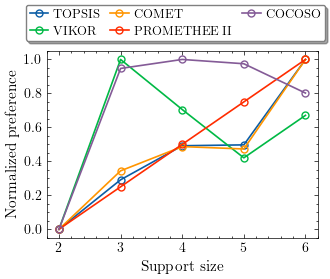

In [19]:
if len(b_bics) > 2:
    selected_alternatives = np.sort(np.argsort(b_bics)[:5])
    # weighting options: 'entropy_weights', 'angle_weights', 'gini_weights', 'variance_weights'
    # selected_criteria = range(len(F.T)); update_weights = False; weighting_method = 'variance_weights'
    selected_criteria = [0, 1, 2, 3, 5, 7]; update_weights = False; weighting_method = 'variance_weights'
    
    # preprocessing / normalization
    rel0 = lambda _: _ - _.min()
    rel1 = lambda _: _ / _.min()
    nF = F.copy()
    # complexity
    nF[:, 0] = rel0(nF[:, 0])
    nF[:, 1] = rel0(nF[:, 1])
    # pinball_losses
    nF[:, 2] = rel0(np.log(nF[:, 2]))
    # pde_uncertainty, error_bars
    nF[:, 3] = np.log(rel1(nF[:, 3]))
    nF[:, 4] = np.log(rel1(nF[:, 4]))
    # miscalibration, discrimination
    nF[:, 5] = rel0(np.log(nF[:, 5]))
    nF[:, 6] = rel0(np.log(nF[:, 6]))
    # criterion_width_criterion
    nF[:, 7] = rel0(np.log(nF[:, 7]))
    
    # types (-1 for min / +1 for max) and obj_w
    types = np.array([-1, -1, -1, -1, -1, -1, +1, cwc_objective])
    nF = nF[:, selected_criteria]
    types = types[selected_criteria]
    obj_weights = getattr(obj_w, weighting_method)(nF, types=types)
    
    # recursive mcdm
    mcdm_iters = len(nF)
    min_alternatives = 0
    filtered_F = nF[selected_alternatives].copy()
    filtered_indices = selected_alternatives.copy()
    winners = []
    first_prefs = None
    
    while len(filtered_F) > min_alternatives and mcdm_iters > 0:
        if len(filtered_F) == 1:
            winners.append({
                'original_index': filtered_indices[0],
                'borda_score': 1.0,
                'borda_count': 1,
                'prefs': None,
                'n_alternatives': 1,
                'full_borda_counts': np.array([1]),
                'full_ranking': filtered_indices.copy(),
            })
            break
    
        if update_weights:
            obj_weights = getattr(obj_w, weighting_method)(filtered_F, types=types)
    
        ranks, prefs = mcdm(filtered_F, obj_weights, types)
    
        if first_prefs is None:
            first_prefs = prefs
    
        # Rank aggregation (bd=Borda, ky=Kemeny-Young, sc=Schulze)
        raw_mcdm_ranks = np.array(ranks).T.astype(np.int32)
        try:
            # agg_ranks = rank_aggregation(raw_mcdm_ranks).run_methods(methods=['bd', 'ky', 'sc']).values
            agg_ranks = rank_aggregation(raw_mcdm_ranks).run_methods(methods=['bd', 'sc', 'ky', 'pl', 'pg']).values
        except TypeError:
            # agg_ranks = rank_aggregation(raw_mcdm_ranks).run_methods(methods=['bd', 'fky', 'sc']).values
            agg_ranks = rank_aggregation(raw_mcdm_ranks).run_methods(methods=['bd', 'sc', 'fky', 'pl', 'pg']).values
        # agg_ranks is (n_alts, n_agg_methods), already proper 1-to-n ranks — just transpose
        ranks = agg_ranks.T  # (n_agg_methods, n_alts)
        n_alts = len(filtered_F)
        borda_counts = np.sum([n_alts + 1 - r for r in ranks], axis=0)
        print(ranks)
    
        # Deterministic tiebreaker:
        # 1. most rank-1 wins across aggregation methods
        # 2. highest borda count
        # 3. highest original index (more terms preferred)
        rank1_wins = np.sum(ranks == 1, axis=0)
        best_local = np.lexsort((-filtered_indices, -borda_counts, -rank1_wins))[0]
        best_original = filtered_indices[best_local]
    
        winners.append({
            'original_index': best_original,
            'borda_score': borda_counts[best_local] / borda_counts.sum(),
            'borda_count': borda_counts[best_local],
            'prefs': prefs[:, best_local],
            'n_alternatives': n_alts,
            'full_borda_counts': borda_counts,
            'full_ranking': filtered_indices[np.lexsort((-filtered_indices, -rank1_wins, -borda_counts))],
        })
    
        # Remove the winner from the pool
        mask = np.ones(n_alts, dtype=bool)
        mask[best_local] = False
        filtered_F = filtered_F[mask]
        filtered_indices = filtered_indices[mask]
        mcdm_iters -= 1
    
    # Results
    print("Winners per iteration:")
    for i, w in enumerate(winners):
        print(f"  Iter {i+1}: alt {w['original_index']}, "
              f"borda={w['borda_count']} ({w['borda_score']:.1%}), "
              f"pool={w['n_alternatives']}")
    print(f"\nFinal ranking by elimination: "
          f"{[w['original_index'] for w in winners]}")
    
    # Visualization
    # Normalize for plotting: scale each method to [0, 1], flip dispreference methods
    all_dispreference = [False, True, False, False, False]  # VIKOR is (-)
    plot_prefs = first_prefs.copy()
    
    for i in range(plot_prefs.shape[0]):
        row = plot_prefs[i]
        mn, mx = row.min(), row.max()
        if mx > mn:
            plot_prefs[i] = (row - mn) / (mx - mn)
        else:
            plot_prefs[i] = np.ones_like(row)
        if all_dispreference[i]:
            plot_prefs[i] = 1 - plot_prefs[i]
    
    with plt.style.context('science'):
        fig, ax = plt.subplots(figsize=(3.5, 3))
        marker_kw = dict(markersize=5, markerfacecolor='none', linewidth=1.2)
        legend_kw = dict(fontsize=9, frameon=True, fancybox=True, shadow=True,
                         edgecolor='grey', handlelength=1.5, handletextpad=0.4,
                         borderpad=0.3, columnspacing=0.8)
        methods = ["TOPSIS", "VIKOR", "COMET", "PROMETHEE II", "COCOSO"]
        for i, name in enumerate(methods):
            ax.plot(selected_alternatives + 1, plot_prefs[i], '-o', **marker_kw, label=name)
        ax.set_xticks(selected_alternatives + 1)
        ax.set_xlabel('Support size', fontsize=11)
        ax.set_ylabel('Normalized preference', fontsize=11)
        ax.legend(loc='lower center', bbox_to_anchor=(0.475, 1.02), ncol=3, **legend_kw)
        fig.tight_layout()
        plt.show()
else:
    print(np.argmin(b_bics))

Winners per iteration:
  Iter 1: alt 5, score=0.895, pool=5
  Iter 2: alt 3, score=0.883, pool=4
  Iter 3: alt 4, score=0.853, pool=3
  Iter 4: alt 2, score=0.800, pool=2
  Iter 5: alt 1, score=1.000, pool=1

Final ranking by elimination: [5, 3, 4, 2, 1]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


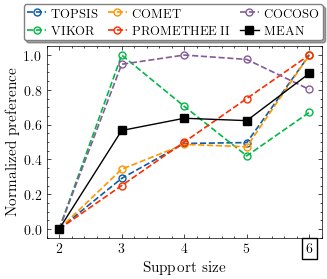

In [20]:
if len(b_bics) > 2:
    selected_alternatives = np.sort(np.argsort(b_bics)[:5])
    # weighting options: 'entropy_weights', 'angle_weights', 'gini_weights', 'variance_weights'
    # selected_criteria = range(len(F.T)); update_weights = False; weighting_method = 'variance_weights'
    selected_criteria = [0, 1, 2, 3, 5, 7]; update_weights = False; weighting_method = 'variance_weights'
    
    # preprocessing / normalization
    rel0 = lambda _: _ - _.min()
    rel1 = lambda _: _ / _.min()
    nF = F.copy()
    # complexity
    nF[:, 0] = rel0(nF[:, 0])
    nF[:, 1] = rel0(nF[:, 1])
    # pinball_losses
    nF[:, 2] = rel0(np.log(nF[:, 2]))
    # pde_uncertainty, error_bars
    nF[:, 3] = np.log(rel1(nF[:, 3]))
    nF[:, 4] = np.log(rel1(nF[:, 4]))
    # miscalibration, discrimination
    nF[:, 5] = rel0(np.log(nF[:, 5]))
    nF[:, 6] = rel0(np.log(nF[:, 6]))
    # criterion_width_criterion
    nF[:, 7] = rel0(np.log(nF[:, 7]))
    
    # types (-1 for min / +1 for max) and obj_w
    types = np.array([-1, -1, -1, -1, -1, -1, +1, cwc_objective])
    nF = nF[:, selected_criteria]
    types = types[selected_criteria]
    obj_weights = getattr(obj_w, weighting_method)(nF, types=types)
    
    # recursive mcdm
    mcdm_iters = len(nF)
    min_alternatives = 0
    filtered_F = nF[selected_alternatives].copy()
    filtered_indices = selected_alternatives.copy()
    is_dispreference = [False, True, False, False, False]  # VIKOR is (-)
    winners = []
    first_prefs = None
    
    while len(filtered_F) > min_alternatives and mcdm_iters > 0:
        if len(filtered_F) == 1:
            winners.append({
                'original_index': filtered_indices[0],
                'score': 1.0,
                'prefs': None,
                'n_alternatives': 1,
                'full_scores': np.array([1.0]),
                'full_ranking': filtered_indices.copy(),
            })
            break
    
        if update_weights:
            obj_weights = getattr(obj_w, weighting_method)(filtered_F, types=types)
    
        _, prefs = mcdm(filtered_F, obj_weights, types)
    
        if first_prefs is None:
            first_prefs = prefs.copy()
    
        # Normalize each method to [0, 1], flip dispreference methods
        norm_prefs = prefs.copy()
        for i in range(norm_prefs.shape[0]):
            mn, mx = norm_prefs[i].min(), norm_prefs[i].max()
            if mx > mn:
                norm_prefs[i] = (norm_prefs[i] - mn) / (mx - mn)
            else:
                norm_prefs[i] = np.ones_like(norm_prefs[i])
            if is_dispreference[i]:
                norm_prefs[i] = 1 - norm_prefs[i]
    
        # Sum of normalized preferences across all methods (higher = better)
        scores = np.mean(norm_prefs, axis=0)
    
        # Deterministic tiebreaker: highest score, then highest original index
        best_local = np.lexsort((-filtered_indices, -scores))[0]
        best_original = filtered_indices[best_local]
    
        winners.append({
            'original_index': best_original,
            'score': scores[best_local],
            'prefs': prefs[:, best_local],
            'n_alternatives': len(filtered_F),
            'full_scores': scores,
            'full_ranking': filtered_indices[np.lexsort((-filtered_indices, -scores))],
        })
    
        # Remove the winner from the pool
        mask = np.ones(len(filtered_F), dtype=bool)
        mask[best_local] = False
        filtered_F = filtered_F[mask]
        filtered_indices = filtered_indices[mask]
        mcdm_iters -= 1
    
    # Results
    print("Winners per iteration:")
    for i, w in enumerate(winners):
        print(f"  Iter {i+1}: alt {w['original_index']}, "
              f"score={w['score']:.3f}, "
              f"pool={w['n_alternatives']}")
    print(f"\nFinal ranking by elimination: "
          f"{[w['original_index'] for w in winners]}")
    
    # Visualization
    plot_prefs = first_prefs.copy()
    for i in range(plot_prefs.shape[0]):
        mn, mx = plot_prefs[i].min(), plot_prefs[i].max()
        if mx > mn:
            plot_prefs[i] = (plot_prefs[i] - mn) / (mx - mn)
        else:
            plot_prefs[i] = np.ones_like(plot_prefs[i])
        if is_dispreference[i]:
            plot_prefs[i] = 1 - plot_prefs[i]
    
    with plt.style.context('science'):
        fig, ax = plt.subplots(figsize=(3.5, 3))
        marker_kw = dict(markersize=5, markerfacecolor='none', linewidth=1.2)
        legend_kw = dict(fontsize=9, frameon=True, fancybox=True, shadow=True,
                         edgecolor='grey', handlelength=1.5, handletextpad=0.4,
                         borderpad=0.3, columnspacing=0.8)
        methods = ["TOPSIS", "VIKOR", "COMET", "PROMETHEE II", "COCOSO"]
        for i, name in enumerate(methods):
            ax.plot(selected_alternatives + 1, plot_prefs[i], '--o', **marker_kw, label=name)
        ax.plot(selected_alternatives + 1, np.mean(plot_prefs, axis=0), '-s', color='black', label='MEAN', zorder=5)
        ax.set_xticks(selected_alternatives + 1)
        ax.set_xlabel('Support size', fontsize=11)
        ax.set_ylabel('Normalized preference', fontsize=11)
        ax.legend(loc='lower center', bbox_to_anchor=(0.46, 1.), ncol=3, **legend_kw)
        for i, label in enumerate(ax.get_xticklabels()):
            if i == len(ax.get_xticklabels()) - 1:
                label.set_bbox(dict(boxstyle='square, pad=0.3', edgecolor='black', facecolor='none'))
        fig.tight_layout()
        fig.savefig(f"../Figures/mcdm_GS_{target_name}.png", dpi=600)
        fig.savefig(f"../Figures/mcdm_GS_{target_name}.eps")
        fig.savefig(f"../Figures/mcdm_GS_{target_name}.pdf")
        plt.show()
else:
    print(np.argmin(b_bics))

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


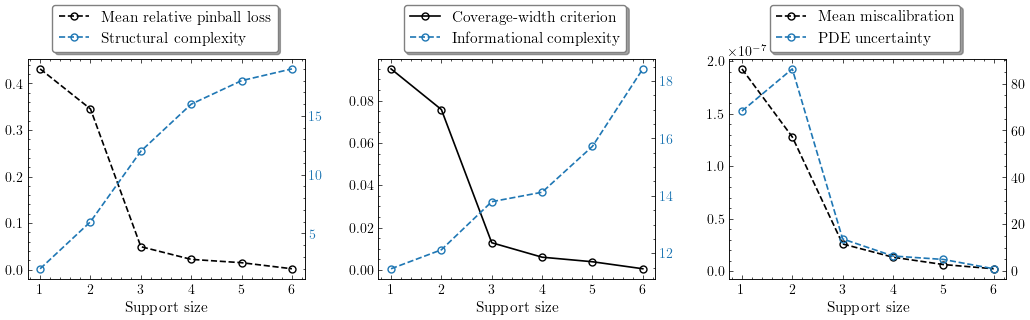

In [21]:
with plt.style.context('science'):
    figsize = 3.5; ncols = 3
    fig, (ax1l, ax2l, ax3l) = plt.subplots(figsize=(figsize*ncols, ncols), ncols=ncols)

    marker_kw = dict(markersize=5, markerfacecolor='none', linewidth=1.2)

    # --- Panel 1: Pinball loss and Structural complexity ---
    ax1r = ax1l.twinx()
    ax1l.plot(complexities, pinball_losses, '--o', c='black', **marker_kw, label='Mean relative pinball loss')
    ax1r.plot(complexities, model_complexities, '--o', c='tab:blue', **marker_kw, label='Structural complexity')
    ax1l.set_xticks(complexities)
    ax1l.set_xlabel('Support size', fontsize=11)
    ax1r.tick_params(axis='y', labelcolor='tab:blue')

    # --- Panel 2: Coverage-width criterion and Informational complexity ---
    ax2r = ax2l.twinx()
    ax2l.plot(complexities, coverage_width_criteria, '-o', c='black', **marker_kw, label='Coverage-width criterion')
    ax2r.plot(complexities, informational_complexities, '--o', c='tab:blue', **marker_kw, label='Informational complexity')
    ax2l.set_xticks(complexities)
    ax2l.set_xlabel('Support size', fontsize=11)
    ax2r.tick_params(axis='y', labelcolor='tab:blue')

    # --- Panel 3: Mean miscalibration and PDE uncertainty ---
    ax3r = ax3l.twinx()
    ax3l.plot(complexities, miscalibration, '--o', c='black', **marker_kw, label='Mean miscalibration')
    ax3r.plot(complexities, pde_uncertainties, '--o', c='tab:blue', **marker_kw, label='PDE uncertainty')
    ax3l.set_xticks(complexities)
    ax3l.set_xlabel('Support size', fontsize=11)

    # --- Per-panel legends ---
    for _, axlr in enumerate([[ax1l, ax1r], [ax2l, ax2r], [ax3l, ax3r]]):
        handles, labels = [], []
        for ax in axlr:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        fig.legend(handles, labels, loc='upper center',
                   bbox_to_anchor=(1/ncols*_+1/(2*ncols), 1.11),
                   ncol=1, fontsize=11,
                   frameon=True, fancybox=True, shadow=True, edgecolor='grey')

    fig.tight_layout()
    fig.savefig(f"../Figures/criteria_GS_{target_name}.png", dpi=600)
    fig.savefig(f"../Figures/criteria_GS_{target_name}.eps")
    fig.savefig(f"../Figures/criteria_GS_{target_name}.pdf")
    plt.show()

### UBIC

In [22]:
tau = 3
verbose = True
# scale = 1 <- generalized UBIC
scale = np.log(len(y_pre))
per = 75 # 80

post_means, b_bics, b_uns = baye_uncertainties(best_subsets, (X_pre_top, y_pre), 
                                               u_type='cv1', take_sqrt=True, 
                                               ridge_lambda=0, 
                                               threshold=0)
# b_uns = ard_uns # USE ard_uns INSTEAD
predictions = X_pre_top@post_means
print(b_bics)
print(b_uns)
b_bics = np.array(b_bics)
max_complexity = len(b_bics)
complexities = np.arange(max_complexity)+1
d_complexities = complexities[decreasing_values_indices(b_bics)]
d_bics = b_bics[decreasing_values_indices(b_bics)]
slopes = np.diff(d_bics)/(np.diff(d_complexities)*d_bics[:-1])
try:
    thres = np.percentile(np.abs(slopes), per)
    # None / Round / Ceil / Floor: Decided by researchers to automate the model selection process
    thres = np.round(sci_format(thres)[0])*10**sci_format(thres)[1]
except IndexError:
    thres = 1/40
min_thres = 1/40; max_thres = 1/10
thres = min(max(thres, min_thres), min_thres)
print("threshold:", thres)

lower_bounds = []
for k, efi in enumerate(best_subsets):
    # assert len(efi) == np.count_nonzero(post_means[:, k:k+1])
    com = len(efi)
    lower_bound = 2*np.abs(log_like_value(predictions[:, k:k+1], y_pre))-np.log(len(y_pre))*com
    lower_bounds.append(lower_bound)

last_lam = np.log10(max(lower_bounds/(b_uns*scale)))
print("max_lam:", last_lam)
delta = last_lam/tau
now_lam = last_lam-delta
last_ubic = UBIC(b_bics, b_uns, len(y_pre), hyp=10**last_lam, scale=scale)
last_bc = np.argmin(last_ubic)
bc_seq = [last_bc]
while now_lam >= 0:
    now_ubic = UBIC(b_bics, b_uns, len(y_pre), hyp=10**now_lam, scale=scale)
    now_bc = np.argmin(now_ubic)
    
    diff_com = now_bc-last_bc
    diff_bic = b_bics[now_bc]-b_bics[last_bc]
    imp = np.nan
    if diff_com != 0:
        imp = abs(diff_bic/(b_bics[last_bc]*diff_com))
    
    if verbose:
        print(min(last_bc, now_bc), '<--->', max(last_bc, now_bc), 
              np.nan_to_num(imp, nan=np.inf))
    
    if (diff_com > 0 and (diff_bic > 0 or imp < thres)) or \
        (diff_com < 0 and diff_bic > 0 and imp > thres):
        break
    
    last_lam = now_lam
    now_lam = round(last_lam-delta, 8)
    last_ubic = now_ubic
    last_bc = now_bc
    if last_bc not in bc_seq:
        bc_seq.append(last_bc)

# best_bc = knee(range(len(last_ubic)), last_ubic, 0.95, 'linear', direction='decreasing')
best_bc = knee_finder(last_ubic)
if best_bc == 0 and last_bc != 0 and b_bics[last_bc] < b_bics[0] and \
                                    abs((b_bics[last_bc]-b_bics[0])/(b_bics[0]*last_bc)) > thres:
    best_bc = knee(range(1, len(last_ubic)), last_ubic[1:], 0.95, 'linear')
if best_bc < last_bc and abs((b_bics[last_bc]-b_bics[best_bc])/(b_bics[best_bc]*(last_bc-best_bc))) > thres:
    best_bc = last_bc
    
last_lam = round(last_lam, 8)
last_lam, last_ubic, last_bc, best_bc

[-205314.6969952415, -209341.31630999676, -249341.96800445692, -264979.3387083167, -271329.86099868023, -313737.70052884077]
[40.93323091 70.43904227  9.91303145  5.80991448  7.44950223  1.        ]
threshold: 0.025
max_lam: 4.532291029132086
5 <---> 5 inf
5 <---> 5 inf
5 <---> 5 inf


(0.0,
 array([-204937.68800605, -208692.54875518, -249250.66561066,
        -264925.82741843, -271261.24854758, -313728.49018847]),
 5,
 5)

### Log evidence

In [23]:
for standardize in (True, False):
    improvement_threshold = thres # 0.1
    dvi = set(decreasing_values_indices(b_bics))
    sel = 0; sel_v = 0
    imp_track = {}
    for v in np.arange(0.05, 0.55, 0.05):
        new_sel = np.argmax([log_evidence(X_pre_top[:, bs], y_pre, v=v, standardize=standardize) for bs in best_subsets])
        
        if new_sel > np.argmin(b_bics):
            break
            
        if new_sel > sel:
            if knee_finder(b_bics) <= new_sel and new_sel in dvi:
                imp = abs((b_bics[new_sel]-b_bics[sel])/(complexities[new_sel]-complexities[sel])/b_bics[sel])
                imp_track[v] = imp
                if imp > improvement_threshold:
                    sel = new_sel
                    sel_v = v
        else:
            sel_v = v
    
    if len(imp_track) > 0:
        sel_v = [sel_v for sel_v, _ in imp_track.items() if _ == max(imp_track.values())][-1] if sel_v == 0 else sel_v
        relative_log_evidences = np.array([log_evidence(X_pre_top[:, bs], y_pre, v=sel_v, standardize=standardize) for bs in best_subsets])
        relative_log_evidences -= relative_log_evidences.min()

sel_v, np.argmax(relative_log_evidences)

(0.5, 5)

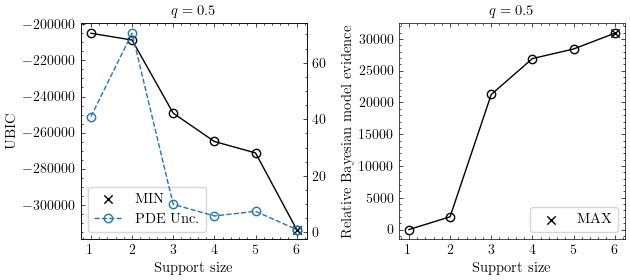

In [24]:
with plt.style.context('science'):
    fig, (ax1l, ax2) = plt.subplots(1, 2, figsize=(6.5, 3))
    
    # UBIC and PDE Uncertainty
    ax1r = ax1l.twinx()
    ax1l.plot(complexities, last_ubic, '-o', c='black', markerfacecolor='none')
    ax1l.scatter(complexities[best_bc], last_ubic[best_bc], marker='x', c='black', label='MIN')
    ax1r.plot(complexities, b_uns, '--o', c='tab:blue', markerfacecolor='none', label='PDE Unc.')
    ax1l.set_xticks(complexities)
    ax1l.set_xlabel('Support size', fontsize=10.5)
    ax1l.set_ylabel('UBIC', fontsize=10.5)
    ax1l.set_title(f'$q = {round(fdr, 2)}$', fontsize=10.5)
    handles = []
    labels = []
    for ax in [ax1l, ax1r]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    ax1l.legend(handles, labels, loc='lower left', fontsize=10.5,frameon=True)
    
    # Relative Bayesian model evidence
    ax2.plot(complexities, relative_log_evidences, '-o', c='black', markerfacecolor='none')
    ax2.scatter(complexities[np.argmax(relative_log_evidences)], relative_log_evidences[np.argmax(relative_log_evidences)], 
                marker='x', c='black', label='MAX')
    ax2.set_xticks(complexities)
    ax2.set_xlabel('Support size', fontsize=10.5)
    ax2.set_ylabel('Relative Bayesian model evidence', fontsize=10.5)
    ax2.set_title(f'$q = {round(fdr, 2)}$', fontsize=10.5)
    ax2.legend(loc='lower right', fontsize=10.5, frameon=True)
    
    plt.tight_layout()
    plt.show()

In [25]:
# _, best_subsets = brute_force_all_subsets(X_pre_top, y_pre, max_support_size=8)
# ebics = []
# mbics = []
# for _ in best_subsets:
#     loglik = log_like_value(X_pre_top[:, _]@np.linalg.lstsq(X_pre_top[:, _], y_pre, rcond=None)[0], 
#                             y_pre)
#     ebics.append(ebic(loglik, len(_), len(y_pre), X_pre_top.shape[-1], const=0))
#     mbics.append(mbic(loglik, len(_), len(y_pre), X_pre_top.shape[-1], const=2))
# ebics = np.array(ebics)
# mbics = np.array(mbics)

In [26]:
# # Assume that mbics is a decreasing sequence
# complexities = np.array([len(_) for _ in best_subsets])
# if np.alltrue(np.array(mbics) >= np.array([max(mbics)+_*(min(mbics)-max(mbics))/(np.argmin(mbics)-np.argmax(mbics)) for _ in range(len(best_subsets))])):
#     knee = complexities.max()
# else:
#     decreasing_indices = np.array(mbics) <= np.array([max(mbics)+_*(min(mbics)-max(mbics))/(np.argmin(mbics)-np.argmax(mbics)) for _ in range(len(best_subsets))])
#     knee = knee_finder(mbics[decreasing_indices])
#     knee = (complexities[decreasing_indices])[knee]
# knee

In [27]:
# SEED = 1234
# np.random.seed(SEED); random.seed(SEED)
# n_samples = int(250*knee)
# false_discovery_control_method = None
# fdr_data = []
# for bs in best_subsets:
#     fdrs = []
#     for _ in range(len(y_pre)//n_samples):
#         X_test = X_pre_top[:, bs]
#         y_test = y_pre.ravel()
        
#         np.random.seed(random.randint(0, 100))
#         # sample_indices = sorted(set([np.random.randint(len(y_pre)) for _ in range(n_samples)]))
#         sample_indices = fpsample.bucket_fps_kdline_sampling(X_test, n_samples=n_samples, h=3) # Farthest Point Sampling (FPS) is better!!!
#         X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
#         # FPS + k-DPP
#         DPP = FiniteDPP('likelihood', **{'L': X_test.dot(X_test.T)})
#         DPP.flush_samples()
#         for _ in range(n_samples//(len(bs))):
#             DPP.sample_exact_k_dpp(size=len(bs))
#         sample_indices = np.unique(np.ravel(DPP.list_of_samples))
#         X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        
#         manager = stepwise_selective_inference(support_size=X_test.shape[1])
#         M, p_list = manager.inference(X_test, y_test, np.std(y_test))
#         if false_discovery_control_method is not None:
#             p_list = stats.false_discovery_control(p_list, method=false_discovery_control_method)
            
#         fdrs.append(subset_fdr(p_list))
        
#     fdrs = np.array(fdrs)
#     if fdrs.mean() < 1:
#         print(len(bs), fdrs.mean())
#         fdr_data.append(fdrs)
        
# fdr_data = np.array(fdr_data)

# from sklearn.cluster import AffinityPropagation, KMeans
# print(AffinityPropagation().fit(fdr_data).labels_)
# print(KMeans(n_clusters=2).fit(fdr_data).labels_)

In [28]:
# SEED = 1234
# np.random.seed(SEED); random.seed(SEED)
# n_samples = int(250*knee)
# false_discovery_control_method = 'by'
# fdr_data = []
# for bs in best_subsets:
#     fdrs = []
#     for _ in range(len(y_pre)//n_samples):
#         X_test = X_pre_top[:, bs]
#         y_test = y_pre.ravel()
        
#         np.random.seed(random.randint(0, 100))
#         # sample_indices = sorted(set([np.random.randint(len(y_pre)) for _ in range(n_samples)]))
#         sample_indices = fpsample.bucket_fps_kdline_sampling(X_test, n_samples=n_samples, h=3) # Farthest Point Sampling (FPS) is better!!!
#         X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
#         # FPS + k-DPP
#         DPP = FiniteDPP('likelihood', **{'L': X_test.dot(X_test.T)})
#         DPP.flush_samples()
#         for _ in range(n_samples//(len(bs))):
#             DPP.sample_exact_k_dpp(size=len(bs))
#         sample_indices = np.unique(np.ravel(DPP.list_of_samples))
#         X_test = X_test[sample_indices]; y_test = y_test[sample_indices]
        
#         manager = stepwise_selective_inference(support_size=X_test.shape[1])
#         M, p_list = manager.inference(X_test, y_test, np.std(y_test))
#         if false_discovery_control_method is not None:
#             p_list = stats.false_discovery_control(p_list, method=false_discovery_control_method)
            
#         fdrs.append(subset_fdr(p_list))
        
#     fdrs = np.array(fdrs)
#     if fdrs.mean() < 1:
#         print(len(bs), fdrs.mean())
#         fdr_data.append(fdrs)
        
# fdr_data = np.array(fdr_data)